[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter18_seminar_notebook.ipynb)

# Modelling Financial Markets — Seminar 18: Systemic Risk and Networks

*Seminar notebook. Daniel Traian Pele, Antoaneta Amza, Bucharest University of Economic Studies.*

- **[Solved]** problems contain the full solution; **[Proposed]** problems name their model (the solved problem with the same technique).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_18'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


> The solutions are discussed in the seminar.

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.stats import spearmanr
import statsmodels.api as sm
from statsmodels.regression.quantile_regression import QuantReg
from sklearn.linear_model import QuantileRegressor, ElasticNetCV
from scipy import optimize
try:
    from arch import arch_model
except ImportError:                      # Colab: pachetul arch nu este preinstalat
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'arch'])
    from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [ ]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Teal     = '#17A2B8'
Gray     = '#7F7F7F'   # doar linii de referinta, benzi, grila
REGION_COL = {'US': MainBlue, 'EU': IDAred, 'RO': Forest}
REGION_LAB = {'US': 'US banks', 'EU': 'European banks', 'RO': 'Romanian banks (BVB)'}
EVENTS = [('2011-08-08', 'Euro crisis'), ('2016-06-24', 'Brexit vote'), ('2018-12-19', 'RO bank tax'),
          ('2020-03-16', 'COVID-19'), ('2023-03-13', 'SVB'), ('2025-04-07', 'Tariffs')]

HERE = '.'
SEED = 42
B_BOOT = 999
RESULTS = {}


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def jsonable(x):
    if isinstance(x, dict):
        return {str(k): jsonable(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [jsonable(v) for v in x]
    if isinstance(x, np.ndarray):
        return [jsonable(v) for v in x.tolist()]
    if isinstance(x, (np.floating, np.integer)):
        return x.item()
    if isinstance(x, pd.Timestamp):
        return str(x.date())
    return x


def mark_events(ax, ymax=None):
    """Linii verticale de referinta pentru evenimente, cu eticheta neagra."""
    for d, lab in EVENTS:
        t = pd.Timestamp(d)
        if ax.get_xlim()[0] <= mdates.date2num(t) <= ax.get_xlim()[1]:
            ax.axvline(t, color=Gray, lw=0.5, ls=':')
            ax.text(t, ax.get_ylim()[1] if ymax is None else ymax, lab, rotation=90, fontsize=6.5, color='black',
                    ha='right', va='top')


import tempfile
HERE = tempfile.gettempdir()   # intermediate tables are written to a temporary folder


def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()

## Data

- Daily prices, January 2010 – 18 September 2026: six US banks, five European banks, Banca Transilvania and BRD; S&P 500, Euro Stoxx 50, BET, VIX.
- Prices joined on common trading days, then daily log returns in %; volatility: daily Parkinson range estimator.
- Romanian banks: days without trades removed.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
START = '2010-01-01'
END = '2026-09-18'

# banca -> (simbol, nume, regiune)
BANKS = {
    'JPM':  ('JPM.US',    'JPMorgan Chase',       'US'),
    'BAC':  ('BAC.US',    'Bank of America',      'US'),
    'C':    ('C.US',      'Citigroup',            'US'),
    'GS':   ('GS.US',     'Goldman Sachs',        'US'),
    'MS':   ('MS.US',     'Morgan Stanley',       'US'),
    'WFC':  ('WFC.US',    'Wells Fargo',          'US'),
    'DBK':  ('DBK.XETRA', 'Deutsche Bank',        'EU'),
    'BNP':  ('BNP.PA',    'BNP Paribas',          'EU'),
    'SAN':  ('SAN.MC',    'Santander',            'EU'),
    'INGA': ('INGA.AS',   'ING',                  'EU'),
    'HSBA': ('HSBA.LSE',  'HSBC',                 'EU'),
    'TLV':  ('TLV.RO',    'Banca Transilvania',   'RO'),
    'BRD':  ('BRD.RO',    'BRD-Groupe SG',        'RO'),
}
US = [k for k, v in BANKS.items() if v[2] == 'US']
EU = [k for k, v in BANKS.items() if v[2] == 'EU']
RO = [k for k, v in BANKS.items() if v[2] == 'RO']
ALL = US + EU + RO
NAMES = {k: v[1] for k, v in BANKS.items()}
INDICES = {'SPX': ('GSPC.INDX', 'S&P 500'), 'SX5E': ('STOXX50E.INDX', 'Euro Stoxx 50'),
           'BET': ('BET', 'BET'), 'VIX': ('VIX.INDX', 'VIX')}
REGION_INDEX = {'US': 'SPX', 'EU': 'SX5E', 'RO': 'BET'}


def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def bank_frame(key, start=START, end=END):
    """OHLCV al unei banci, cu pretul ajustat si corectiile de mai sus."""
    symbol, _, region = BANKS[key]
    d = read_market(symbol).loc[start:end].copy()
    d = d[(d.index.dayofweek < 5) & (d['adjusted_close'] > 0)]
    if region == 'RO':
        d = d[d['volume'] > 0]                                   # zile fara tranzactii
    if key == 'TLV' and pd.Timestamp('2016-05-30') in d.index:
        # ajustarea pentru actiunile gratuite: factorul de dupa data ex se aplica si pe 30 mai 2016
        f = d.loc['2016-05-31', 'adjusted_close'] / d.loc['2016-05-31', 'close']
        d.loc['2016-05-30', 'adjusted_close'] = d.loc['2016-05-30', 'close'] * f
    return d


def bank_price(key, start=START, end=END):
    return bank_frame(key, start, end)['adjusted_close'].rename(key)


def index_close(key, start=START, end=END):
    s = read_market(INDICES[key][0])['close'].loc[start:end]
    s = s[(s.index.dayofweek < 5) & (s > 0)].dropna()
    if key != 'VIX':
        s = s[s.diff() != 0]                                     # sarbatori completate cu pretul anterior
    return s.rename(key)


def prices(keys, start=START, end=END):
    """Preturi zilnice pentru banci si/sau indici, doar in zilele comune."""
    cols = [bank_price(k, start, end) if k in BANKS else index_close(k, start, end) for k in keys]
    return pd.concat(cols, axis=1, join='inner').dropna()


def joint_returns(keys, start=START, end=END):
    """Randamente log zilnice in %: intai join pe PRETURI in zilele comune, apoi randamente."""
    return 100 * np.log(prices(keys, start, end)).diff().dropna()


def bank_range_vol(keys, start=START, end=END):
    """Volatilitatea zilnica Parkinson (in %, anualizata), in zilele comune tuturor bancilor."""
    out = []
    for k in keys:
        d = bank_frame(k, start, end)
        rng = np.log(d['high'] / d['low']).where(d['high'] > d['low'])
        s2 = rng ** 2 / (4 * np.log(2))
        s2 = s2.fillna(s2[s2 > 0].min())                          # zile cu maxim = minim: cea mai mica valoare observata
        out.append((100 * np.sqrt(252 * s2)).rename(k))
    return pd.concat(out, axis=1, join='inner').dropna()


def system_return(R, members):
    """Randamentul sistemului: portofoliul cu ponderi egale al bancilor (randamente log in %, aproximare zilnica)."""
    return R[members].mean(axis=1)


# randamente log zilnice in % (zile comune) si volatilitatea Parkinson (log)
R = joint_returns(ALL + ['SPX', 'SX5E', 'BET', 'VIX'])
V = np.log(bank_range_vol(ALL))
print(R.index[0].date(), '->', R.index[-1].date(), len(R), 'common days')


def system_ex(k, members):
    """Randamentul sistemului regional fara banca k (portofoliu cu ponderi egale)."""
    return R[[j for j in members if j != k]].mean(axis=1)


def region_of(k):
    return BANKS[k][2]

## Systemic risk measures

- `mes`, `lrmes`, `srisk_ratio`, `breakeven_leverage`: exposure measures.
- `qreg`, `covar_static`, `covar_boot`, `covar_dynamic`: CoVaR by quantile regression, with a moving-block bootstrap.
- `var_fit`, `gfevd`, `spillover_table`, `rolling_total`: Diebold–Yilmaz connectedness.
- `lasso_qr_gacv`: L1-penalized quantile regression with the penalty chosen by GACV (Financial Risk Meter).

In [ ]:
def mes(r_i, r_m, alpha=0.05):
    """MES (%): pierderea medie a bancii in zilele in care piata este in coada de probabilitate alpha."""
    q = np.quantile(r_m, alpha)
    return -np.mean(np.asarray(r_i)[np.asarray(r_m) <= q])


def mes_threshold(r_i, r_m, c=-2.0):
    """MES (%) in zilele in care piata scade cu mai mult de |c|% (definitia folosita pentru LRMES)."""
    return -np.mean(np.asarray(r_i)[np.asarray(r_m) < c])


def lrmes(mes2_pct):
    """Pierderea pe termen lung intr-o criza (piata -40% in sase luni): LRMES = 1 - exp(-18 MES), MES in fractii."""
    return 1 - np.exp(-18 * mes2_pct / 100)


def srisk_ratio(lrm, leverage, k=0.08):
    """SRISK / capitalul de piata W: k(L - 1) - (1 - k)(1 - LRMES), cu L = (D + W)/W."""
    return k * (leverage - 1) - (1 - k) * (1 - lrm)


def breakeven_leverage(lrm, k=0.08):
    """Levierul L* peste care SRISK > 0: L* = 1 + (1 - k)(1 - LRMES)/k."""
    return 1 + (1 - k) * (1 - lrm) / k


def qreg(y, X, q):
    """Regresie cuantila (Koenker-Bassett); intoarce coeficientii [termen liber, pante]."""
    return QuantReg(np.asarray(y), sm.add_constant(np.asarray(X), has_constant='add')).fit(q=q, max_iter=5000).params


def covar_static(x_sys, x_i, alpha=0.01):
    """CoVaR si Delta-CoVaR necondiționate (%, pozitive = pierderi).

    Regresia cuantila la nivelul alpha: X_sys = a + b X_i;
    CoVaR_alpha = -(a + b q_alpha(X_i)); Delta-CoVaR = b (q_50(X_i) - q_alpha(X_i))."""
    x_sys, x_i = np.asarray(x_sys), np.asarray(x_i)
    a, b = qreg(x_sys, x_i, alpha)
    qa, qm = np.quantile(x_i, alpha), np.quantile(x_i, 0.5)
    return {'a': a, 'b': b, 'var_i': -qa, 'covar': -(a + b * qa), 'covar_med': -(a + b * qm),
            'dcovar': b * (qm - qa), 'var_sys': -np.quantile(x_sys, alpha)}


def block_bootstrap_idx(n, block=20, rng=None):
    """Indici pentru bootstrap pe blocuri mobile (Künsch), blocuri de lungime fixa."""
    rng = rng or np.random.default_rng(0)
    starts = rng.integers(0, n - block + 1, size=int(np.ceil(n / block)))
    return (starts[:, None] + np.arange(block)[None, :]).ravel()[:n]


def covar_boot(x_sys, x_i, alpha=0.01, B=200, block=20, seed=0):
    """Interval percentil de 95% pentru Delta-CoVaR prin bootstrap pe blocuri mobile."""
    x_sys, x_i = np.asarray(x_sys), np.asarray(x_i)
    rng = np.random.default_rng(seed)
    d = []
    for _ in range(B):
        idx = block_bootstrap_idx(len(x_i), block, rng)
        d.append(covar_static(x_sys[idx], x_i[idx], alpha)['dcovar'])
    return np.percentile(d, [2.5, 97.5])


def covar_dynamic(x_sys, x_i, M, alpha=0.01):
    """Delta-CoVaR variabil in timp cu variabile de stare M_{t-1} (Adrian & Brunnermeier, 2016).

    X_i,t = a + c'M_{t-1} la nivelurile alpha si 50%  ->  VaR_i,t;
    X_sys,t = a + b X_i,t + c'M_{t-1} la nivelul alpha  ->  Delta-CoVaR_t = b (q50_i,t - qalpha_i,t)."""
    ci_a = qreg(x_i, M, alpha)
    ci_m = qreg(x_i, M, 0.5)
    cs = qreg(x_sys, np.column_stack([x_i, M]), alpha)
    Mc = sm.add_constant(np.asarray(M), has_constant='add')
    qa, qm = Mc @ ci_a, Mc @ ci_m
    return pd.DataFrame({'var_i': -qa, 'dcovar': cs[1] * (qm - qa)}, index=getattr(x_i, 'index', None)), cs[1]


def var_fit(Y, p):
    """VAR(p) estimat prin OLS; intoarce coeficientii A_1..A_p (k x k) si matricea de covarianta a reziduurilor."""
    Y = np.asarray(Y, float)
    T, k = Y.shape
    X = np.hstack([np.ones((T - p, 1))] + [Y[p - l - 1:T - l - 1] for l in range(p)])
    Yt = Y[p:]
    B = np.linalg.lstsq(X, Yt, rcond=None)[0]
    E = Yt - X @ B
    S = E.T @ E / (len(Yt) - X.shape[1])
    A = [B[1 + l * k:1 + (l + 1) * k].T for l in range(p)]
    return A, S


def var_bic(Y, pmax=5):
    """Ordinul VAR ales prin criteriul BIC."""
    Y = np.asarray(Y, float)
    T, k = Y.shape
    best = None
    for p in range(1, pmax + 1):
        A, S = var_fit(Y[pmax - p:], p)
        n = T - pmax
        bic = np.log(np.linalg.det(S)) + np.log(n) * p * k * k / n
        if best is None or bic < best[1]:
            best = (p, bic)
    return best[0]


def ma_coefs(A, H):
    """Coeficientii reprezentarii medie mobila Phi_0..Phi_{H-1}."""
    k = A[0].shape[0]
    Phi = [np.eye(k)]
    for h in range(1, H):
        Phi.append(sum(A[l] @ Phi[h - l - 1] for l in range(min(h, len(A)))))
    return Phi


def gfevd(A, S, H=10):
    """Descompunerea generalizata a dispersiei erorii de prognoza (Pesaran-Shin), normalizata pe linii."""
    Phi = ma_coefs(A, H)
    k = S.shape[0]
    num = np.zeros((k, k))
    den = np.zeros(k)
    for P in Phi:
        PS = P @ S
        num += PS ** 2
        den += np.diag(P @ S @ P.T)
    theta = num / np.diag(S)[None, :] / den[:, None]
    return theta / theta.sum(axis=1, keepdims=True)


def spillover_table(theta, names):
    """Tabelul de conectivitate: contributii (%), FROM, TO, NET si indicele total."""
    k = theta.shape[0]
    D = 100 * theta
    off = D - np.diag(np.diag(D))
    frm, to = off.sum(axis=1), off.sum(axis=0)
    tab = pd.DataFrame(D, index=names, columns=names)
    return {'table': tab, 'from': pd.Series(frm, index=names), 'to': pd.Series(to, index=names),
            'net': pd.Series(to - frm, index=names), 'total': off.sum() / k,
            'pairwise_net': pd.DataFrame(off.T - off, index=names, columns=names)}


def rolling_total(Y, window=250, step=5, p=2, H=10):
    """Indicele total de conectivitate pe ferestre mobile."""
    Y = pd.DataFrame(Y)
    out, frm_to = {}, {}
    for end in range(window, len(Y) + 1, step):
        w = Y.iloc[end - window:end]
        A, S = var_fit(w.values, p)
        st = spillover_table(gfevd(A, S, H), list(Y.columns))
        out[Y.index[end - 1]] = st['total']
        frm_to[Y.index[end - 1]] = st['net']
    return pd.Series(out), pd.DataFrame(frm_to).T


def check_loss(u, tau):
    return u * (tau - (u < 0))


def lasso_qr_gacv(y, X, tau=0.05, lambdas=None):
    """Regresie cuantila penalizata L1; lambda ales prin GACV = sum rho_tau(rez) / (n - df)."""
    y, X = np.asarray(y, float), np.asarray(X, float)
    n = len(y)
    lambdas = np.logspace(-4, -0.5, 15) if lambdas is None else lambdas
    rows = []
    for lam in lambdas:
        m = QuantileRegressor(quantile=tau, alpha=lam, solver='highs').fit(X, y)
        res = y - m.predict(X)
        df = int(np.sum(np.abs(m.coef_) > 1e-8))
        g = check_loss(res, tau).sum() / max(n - df, 1)
        rows.append((lam, g, df, m.coef_.copy()))
    i = int(np.argmin([r[1] for r in rows]))
    return {'lambda': rows[i][0], 'gacv': [r[1] for r in rows], 'df': [r[2] for r in rows],
            'lambdas': list(lambdas), 'coef': rows[i][3], 'df_sel': rows[i][2]}

In [ ]:
MACRO = ['SPX', 'SX5E', 'VIX']
LAMBDAS = np.logspace(-6, -1.5, 20)
EPISODES = [('GFC: Lehman', '2008-09-01', '2008-11-30'), ('Euro crisis', '2011-07-01', '2011-10-31'), ('Brexit vote', '2016-06-20', '2016-07-15'), ('RO bank tax', '2018-12-10', '2019-01-31'), ('COVID-19', '2020-02-15', '2020-04-30'), ('SVB / Credit Suisse', '2023-03-01', '2023-04-15'), ('Tariff shock', '2025-03-25', '2025-04-30')]
INTL = US + EU

## Seminar functions

- Helper functions from the lecture used in Part B.

In [ ]:
def frm_design():
    """Randamente zilnice (fractii) ale bancilor si variabilele macro intarziate cu o zi."""
    Rf = R / 100
    Mac = Rf[MACRO].shift(1).add_suffix('_lag')
    return Rf[ALL].join(Mac).dropna()


def frm_window(D, k, tau=0.05):
    X = D[[j for j in ALL if j != k] + [c for c in D.columns if c.endswith('_lag')]]
    return lasso_qr_gacv(D[k].values, X.values, tau, LAMBDAS)


def weekly_returns(keys):
    p = prices(keys)
    w = p.resample('W-FRI').last().dropna()
    return 100 * np.log(w).diff().dropna()


def spill_rolling():
    tot, net = rolling_total(V, window=250, step=5, p=2, H=10)
    return tot, net


A5_M = np.array([[70.0, 20.0, 10.0], [25.0, 60.0, 15.0], [5.0, 10.0, 85.0]], float)
A6_M = np.array([[55.0, 25.0, 15.0, 5.0], [20.0, 50.0, 20.0, 10.0], [10.0, 15.0, 65.0, 10.0], [5.0, 5.0, 10.0, 80.0]], float)


def dy_from_matrix(M):
    """Tabelul Diebold-Yilmaz dintr-o matrice de contributii (%, liniile insumeaza 100)."""
    off = M - np.diag(np.diag(M))
    frm, to = off.sum(1), off.sum(0)
    return {'from': frm, 'to': to, 'net': to - frm, 'total': off.sum() / len(M), 'pairwise': (off.T - off)}


def reverse_2f(b, S, target):
    b, S = np.asarray(b, float), np.asarray(S, float)
    sb2 = b @ S @ b
    f = -target * S @ b / sb2
    d = target / np.sqrt(sb2)
    return {'Sb': S @ b, 'sb2': sb2, 'sb': np.sqrt(sb2), 'f': f, 'd': d, 'p': stats.norm.cdf(-d)}


def cholesky_fevd(A, S, H=10, order=None):
    """Descompunerea ortogonala (Cholesky) a dispersiei, pentru o ordine data a variabilelor."""
    k = S.shape[0]
    order = list(range(k)) if order is None else order
    P = np.eye(k)[order]
    Sp = P @ S @ P.T
    L = np.linalg.cholesky(Sp)
    Phi = [P @ F @ P.T for F in ma_coefs(A, H)]
    num = sum((F @ L) ** 2 for F in Phi)
    th = num / num.sum(axis=1, keepdims=True)
    inv = np.argsort(order)
    return th[np.ix_(inv, inv)]

## Inference helpers

- Joint bootstrap tests, GJR-GARCH/DCC simulation, VAR residual bootstrap, backtest.

In [ ]:
B = 999


def holm(p):
    """Corectia Holm (valori p ajustate) pentru o familie de teste."""
    p = np.asarray(p, float)
    o = np.argsort(p)
    m = len(p)
    adj = np.maximum.accumulate((m - np.arange(m)) * p[o])
    out = np.empty(m)
    out[o] = np.minimum(adj, 1)
    return out


def covar_tests(alpha=0.01, B=B, block=20, seed=SEED):
    """Aceleasi extrageri bootstrap pentru toate bancile -> distributia comuna a Delta-CoVaR si a pantelor."""
    banks = US + EU
    sysr = {k: system_ex(k, US if k in US else EU).values for k in banks}
    x = {k: R[k].values for k in banks}
    n = len(R)
    point = {k: covar_static(sysr[k], x[k], alpha) for k in banks}
    b50 = {k: qreg(sysr[k], x[k], 0.5)[1] for k in banks}
    rng = np.random.default_rng(seed)
    D = np.zeros((B, len(banks)))
    DB = np.zeros((B, len(banks)))
    for r in range(B):
        idx = block_bootstrap_idx(n, block, rng)
        for j, k in enumerate(banks):
            c = covar_static(sysr[k][idx], x[k][idx], alpha)
            D[r, j] = c['dcovar']
            DB[r, j] = c['b'] - qreg(sysr[k][idx], x[k][idx], 0.5)[1]
    res = {'alpha': alpha, 'n': n, 'n_tail': n * alpha, 'banks': {}}
    for j, k in enumerate(banks):
        fit = QuantReg(sysr[k], sm.add_constant(x[k])).fit(q=alpha, max_iter=5000)     # s.e. kernel (sandwich)
        dpt = point[k]['b'] - b50[k]
        se_db = DB[:, j].std(ddof=1)
        res['banks'][k] = {'dcovar': point[k]['dcovar'], 'b': point[k]['b'], 'b50': b50[k], 'se_b_kernel': fit.bse[1],
                           'se_b_boot': None, 'lo': np.percentile(D[:, j], 2.5), 'hi': np.percentile(D[:, j], 97.5),
                           'se_dcovar_boot': D[:, j].std(ddof=1), 'db': dpt, 'se_db': se_db,
                           'p_db': 2 * stats.norm.sf(abs(dpt) / se_db)}
    # egalitatea contributiilor pe perechi, in fiecare regiune: t = diferenta / abaterea bootstrap a diferentei
    pairs = []
    for mem in (US, EU):
        for a in range(len(mem)):
            for b_ in range(a + 1, len(mem)):
                i, j = banks.index(mem[a]), banks.index(mem[b_])
                d = point[mem[a]]['dcovar'] - point[mem[b_]]['dcovar']
                se = (D[:, i] - D[:, j]).std(ddof=1)
                pairs.append((mem[a], mem[b_], d, se, 2 * stats.norm.sf(abs(d) / se),
                              # suprapunerea intervalelor marginale
                              not (res['banks'][mem[a]]['hi'] < res['banks'][mem[b_]]['lo'] or
                                   res['banks'][mem[b_]]['hi'] < res['banks'][mem[a]]['lo'])))
    p = np.array([q[4] for q in pairs])
    ph = holm(p)
    res['pairs'] = [{'a': q[0], 'b': q[1], 'd': q[2], 'se': q[3], 'p': q[4], 'p_holm': ph[i], 'overlap': q[5]}
                    for i, q in enumerate(pairs)]
    res['n_pairs'] = len(pairs)
    res['n_sig_raw'] = int((p < 0.05).sum())
    res['n_sig_holm'] = int((ph < 0.05).sum())
    res['n_sig_overlap'] = int(sum(1 for i, q in enumerate(pairs) if q[5] and p[i] < 0.05))
    res['n_db_sig'] = int(sum(v['p_db'] < 0.05 for v in res['banks'].values()))
    res['n_db_sig_holm'] = int((holm([v['p_db'] for v in res['banks'].values()]) < 0.05).sum())
    # test Wald comun: toate Delta-CoVaR egale intr-o regiune (covarianta bootstrap a contrastelor)
    for reg, mem in (('US', US), ('EU', EU)):
        ids = [banks.index(k) for k in mem]
        C = np.zeros((len(ids) - 1, len(banks)))
        for r_, i in enumerate(ids[1:]):
            C[r_, ids[0]], C[r_, i] = 1, -1
        dv = C @ np.array([point[k]['dcovar'] for k in banks])
        S = np.cov((D @ C.T).T)
        w = float(dv @ np.linalg.solve(S, dv))
        res[f'wald_{reg}'] = {'stat': w, 'df': len(ids) - 1, 'p': stats.chi2.sf(w, len(ids) - 1)}
    return res


def ge_covar(alpha=0.05):
    out = {}
    for k in US + EU:
        xs = system_ex(k, US if k in US else EU).values
        xi = R[k].values
        qa, qm = np.quantile(xi, alpha), np.quantile(xi, 0.5)
        dist = xs[xi <= qa]
        med = xs[np.abs(xi - xi.mean()) <= xi.std()]                       # starea de referinta: eveniment de o abatere standard
        out[k] = {'ge_covar': -np.quantile(dist, alpha), 'ge_covar_med': -np.quantile(med, alpha),
                  'ab_covar': covar_static(xs, xi, alpha)['covar'], 'n_cond': int(len(dist))}
        out[k]['ge_dcovar'] = out[k]['ge_covar'] - out[k]['ge_covar_med']
    return out


def kupiec(x, n, p):
    """Testul Kupiec (acoperire neconditionata): LR ~ chi2(1) sub H0: rata de depasire = p."""
    ph = x / n
    ll0 = x * np.log(p) + (n - x) * np.log(1 - p)
    ll1 = (x * np.log(ph) if x > 0 else 0) + ((n - x) * np.log(1 - ph) if x < n else 0)
    lr = -2 * (ll0 - ll1)
    return lr, stats.chi2.sf(lr, 1)


def backtest_ge(alpha=0.05, start=1000):
    """Backtest in afara esantionului al CoVaR Girardi-Ergun (istoric, fereastra extinsa):
    lovitura comuna 1{X_sys <= -CoVaR_t, X_i <= -VaR_i,t}, cu probabilitatea alpha^2 sub H0."""
    out = {}
    for k in US + EU:
        xs = system_ex(k, US if k in US else EU).values
        xi = R[k].values
        hits, vh = [], []
        for t in range(start, len(xi)):
            a, s = xi[:t], xs[:t]
            q = np.quantile(a, alpha)
            cov = -np.quantile(s[a <= q], alpha)
            vh.append(xi[t] <= q)
            hits.append((xi[t] <= q) and (xs[t] <= -cov))
        n, x = len(hits), int(np.sum(hits))
        lr, p = kupiec(x, n, alpha ** 2)
        lrv, pv = kupiec(int(np.sum(vh)), n, alpha)
        out[k] = {'n': n, 'hits': x, 'expected': n * alpha ** 2, 'lr': lr, 'p': p,
                  'var_hits': int(np.sum(vh)), 'var_p': pv}
    return out


def gjr_fit(r):
    """GJR-GARCH(1,1) cu medie zero (randamente log in %), QML."""
    m = arch_model(r, mean='Zero', vol='GARCH', p=1, o=1, q=1, dist='normal', rescale=False).fit(disp='off')
    om, a, g, b = m.params[['omega', 'alpha[1]', 'gamma[1]', 'beta[1]']]
    s2 = m.conditional_volatility ** 2
    s2_next = om + (a + g * (r[-1] < 0)) * r[-1] ** 2 + b * s2[-1]
    return {'omega': om, 'alpha': a, 'gamma': g, 'beta': b, 'sig': np.sqrt(s2), 's2_next': s2_next}


def dcc_fit(e):
    """DCC(1,1) bivariat, al doilea pas al QML (Engle, 2002); e = reziduuri standardizate T x 2."""
    S = np.corrcoef(e.T)
    T = len(e)

    def filt(a, b):
        Q = S.copy()
        rho = np.empty(T)
        for t in range(T):
            rho[t] = Q[0, 1] / np.sqrt(Q[0, 0] * Q[1, 1])
            Q = (1 - a - b) * S + a * np.outer(e[t], e[t]) + b * Q
        return rho, Q

    def nll(th):
        a, b = th
        if a <= 0 or b <= 0 or a + b >= 0.999:
            return 1e10
        rho, _ = filt(a, b)
        z1, z2 = e[:, 0], e[:, 1]
        return 0.5 * np.sum(np.log(1 - rho ** 2) + (z1 ** 2 + z2 ** 2 - 2 * rho * z1 * z2) / (1 - rho ** 2)
                            - (z1 ** 2 + z2 ** 2))

    best = min((optimize.minimize(nll, x0, method='Nelder-Mead', options={'xatol': 1e-5, 'fatol': 1e-4})
                for x0 in [(0.02, 0.95), (0.05, 0.90)]), key=lambda o: o.fun)
    a, b = best.x
    rho, Q = filt(a, b)
    return {'a': a, 'b': b, 'S': S, 'rho': rho, 'Q_next': Q}


def simulate_market(gm, eps_m, idx):
    """Traiectorii ale pietei (GJR) din inovatiile reesantionate eps_m[idx], idx: S x h."""
    Sn, h = idx.shape
    s2 = np.full(Sn, gm['s2_next'])
    cum = np.zeros(Sn)
    for t in range(h):
        r = np.sqrt(s2) * eps_m[idx[:, t]]
        cum += r
        s2 = gm['omega'] + (gm['alpha'] + gm['gamma'] * (r < 0)) * r ** 2 + gm['beta'] * s2
    return cum


def simulate_firm(gf, gm, dcc, eps_m, xi, idx):
    """Traiectoriile bancii conditionate pe aceleasi date extrase (Anexa A din Brownlees & Engle, 2017)."""
    Sn, h = idx.shape
    s2i = np.full(Sn, gf['s2_next'])
    q11 = np.full(Sn, dcc['Q_next'][0, 0])
    q22 = np.full(Sn, dcc['Q_next'][1, 1])
    q12 = np.full(Sn, dcc['Q_next'][0, 1])
    cum = np.zeros(Sn)
    a, b, S = dcc['a'], dcc['b'], dcc['S']
    for t in range(h):
        rho = q12 / np.sqrt(q11 * q22)
        em = eps_m[idx[:, t]]
        ei = rho * em + np.sqrt(1 - rho ** 2) * xi[idx[:, t]]
        r = np.sqrt(s2i) * ei
        cum += r
        s2i = gf['omega'] + (gf['alpha'] + gf['gamma'] * (r < 0)) * r ** 2 + gf['beta'] * s2i
        q11 = (1 - a - b) * S[0, 0] + a * ei ** 2 + b * q11
        q22 = (1 - a - b) * S[1, 1] + a * em ** 2 + b * q22
        q12 = (1 - a - b) * S[0, 1] + a * ei * em + b * q12
    return cum


def _sim_gauss_market(gm, eps):
    Sn, h = eps.shape
    s2 = np.full(Sn, gm['s2_next'])
    cum = np.zeros(Sn)
    for t in range(h):
        r = np.sqrt(s2) * eps[:, t]
        cum += r
        s2 = gm['omega'] + (gm['alpha'] + gm['gamma'] * (r < 0)) * r ** 2 + gm['beta'] * s2
    return cum


def _sim_gauss_firm(gf, gm, dcc, eps_m_paths, rng):
    """Varianta cu inovatii Normale (aceleasi traiectorii de criza ale pietei, xi ~ N(0,1))."""
    Sn, h = eps_m_paths.shape
    xi = rng.standard_normal((Sn, h))
    s2i = np.full(Sn, gf['s2_next'])
    q11, q22, q12 = (np.full(Sn, dcc['Q_next'][i, j]) for i, j in [(0, 0), (1, 1), (0, 1)])
    a, b, S = dcc['a'], dcc['b'], dcc['S']
    cum = np.zeros(Sn)
    for t in range(h):
        rho = q12 / np.sqrt(q11 * q22)
        em = eps_m_paths[:, t]
        ei = rho * em + np.sqrt(1 - rho ** 2) * xi[:, t]
        r = np.sqrt(s2i) * ei
        cum += r
        s2i = gf['omega'] + (gf['alpha'] + gf['gamma'] * (r < 0)) * r ** 2 + gf['beta'] * s2i
        q11 = (1 - a - b) * S[0, 0] + a * ei ** 2 + b * q11
        q22 = (1 - a - b) * S[1, 1] + a * em ** 2 + b * q22
        q12 = (1 - a - b) * S[0, 1] + a * ei * em + b * q12
    return cum


def lrmes_sim(end, h, C, Sn, seed=SEED, gaussian=False):
    """LRMES (fractie) pentru cele 13 banci la data `end`, orizont h zile, prag C (randament aritmetic al pietei)."""
    rng = np.random.default_rng(seed)
    Rs = R.loc[:end]
    out, info = {}, {}
    for reg, mem in (('US', US), ('EU', EU), ('RO', RO)):
        rm = Rs[REGION_INDEX[reg]].values
        gm = gjr_fit(rm)
        eps_m = rm / gm['sig']
        T = len(rm)
        # 1) traiectoriile pietei; se pastreaza doar scenariile de criza (algoritmul din Anexa A)
        keep_idx, n_all = [], 0
        for _ in range(Sn // 20000):
            idx = rng.integers(0, T, size=(20000, h))
            n_all += 20000
            if gaussian:
                eps_draw = rng.standard_normal((20000, h))
                # traiectorii gaussiene: indici catre o matrice proprie de inovatii
                cm = _sim_gauss_market(gm, eps_draw)
                keep_idx.append(eps_draw[np.exp(cm / 100) - 1 < C])
            else:
                cm = simulate_market(gm, eps_m, idx)
                keep_idx.append(idx[np.exp(cm / 100) - 1 < C])
        kept = np.concatenate(keep_idx)
        info[reg] = {'p_crisis': len(kept) / n_all, 'n_crisis': len(kept), 'market': gm}
        for k in mem:
            ri = Rs[k].values
            gf = gjr_fit(ri)
            e = np.column_stack([ri / gf['sig'], eps_m])
            dcc = dcc_fit(e)
            xi = (e[:, 0] - dcc['rho'] * e[:, 1]) / np.sqrt(1 - dcc['rho'] ** 2)
            if gaussian:
                ci = _sim_gauss_firm(gf, gm, dcc, kept, rng)
            else:
                ci = simulate_firm(gf, gm, dcc, eps_m, xi, kept)
            Ri = np.exp(ci / 100) - 1
            out[k] = {'lrmes': -Ri.mean(), 'mc_se': Ri.std(ddof=1) / np.sqrt(len(Ri)),
                      'q05': -np.quantile(Ri, 0.95), 'q95': -np.quantile(Ri, 0.05),
                      'rho_last': dcc['rho'][-1], 'dcc_a': dcc['a'], 'dcc_b': dcc['b'],
                      'gjr': [gf['alpha'], gf['gamma'], gf['beta']]}
    return out, info


def var_simulate(A, c, E, Y0, idx):
    p = len(A)
    T = len(idx)
    k = A[0].shape[0]
    Y = np.zeros((T + p, k))
    Y[:p] = Y0
    for t in range(p, T + p):
        Y[t] = c + sum(A[l] @ Y[t - l - 1] for l in range(p)) + E[idx[t - p]]
    return Y


def var_fit_c(Y, p):
    Y = np.asarray(Y, float)
    T, k = Y.shape
    X = np.hstack([np.ones((T - p, 1))] + [Y[p - l - 1:T - l - 1] for l in range(p)])
    Bc = np.linalg.lstsq(X, Y[p:], rcond=None)[0]
    E = Y[p:] - X @ Bc
    return [Bc[1 + l * k:1 + (l + 1) * k].T for l in range(p)], Bc[0], E


def spill_bootstrap(Y, p, H=10, B=B, block=20, seed=SEED):
    """Interval percentil pentru conectivitatea totala si neta (bootstrap pe blocuri de reziduuri, VAR reestimat)."""
    Y = np.asarray(Y, float)
    A, c, E = var_fit_c(Y, p)
    rng = np.random.default_rng(seed)
    tot, net = [], []
    for _ in range(B):
        idx = block_bootstrap_idx(len(E), block, rng)
        Yb = var_simulate(A, c, E, Y[:p], idx)
        Ab, Sb = var_fit(Yb, p)
        st = spillover_table(gfevd(Ab, Sb, H), list(range(Y.shape[1])))
        tot.append(st['total'])
        net.append(st['net'].values)
    return np.array(tot), np.array(net)

## Part A — derivations

### A1. Deriving CoVaR under the Normal distribution [Solved]

- σ_i = 2%, σ_sys = 1.5%, ρ = 0.6, α = 1%; ΔCoVaR = −ρ σ_sys z_α.

In [8]:
def a1_covar_normal(s_sys=1.5, s_i=2.0, rho=0.6, alpha=0.01):
    """CoVaR sub distributia Normala bivariata cu medii zero."""
    z = stats.norm.ppf(alpha)
    return {'z': z, 'var_i': -s_i * z, 'var_sys': -s_sys * z, 'cond_sd': s_sys * np.sqrt(1 - rho ** 2),
            'covar': -s_sys * z * (rho + np.sqrt(1 - rho ** 2)), 'covar_med': -s_sys * np.sqrt(1 - rho ** 2) * z,
            'dcovar': -rho * s_sys * z}


a1_covar_normal()

{'z': np.float64(-2.3263478740408408),
 'var_i': np.float64(4.6526957480816815),
 'var_sys': np.float64(3.489521811061261),
 'cond_sd': np.float64(1.2000000000000002),
 'covar': np.float64(4.885330535485766),
 'covar_med': np.float64(2.7916174488490095),
 'dcovar': np.float64(2.0937130866367566)}

### A2. The Girardi–Ergün CoVaR under the Normal distribution [Proposed]

- Solve Φ₂(z_α, −c/σ_sys; ρ) = α². Model: A1.

In [ ]:
# Your code here


### A3. MES as an Euler contribution [Solved]

- w = (0.5, 0.5), σ = (2%, 3%), ρ = 0.5, α = 5%: ES of the portfolio = Σ w_i MES_i.

In [10]:
def a3_euler(w=(0.5, 0.5), s=(2.0, 3.0), rho=0.5, alpha=0.05):
    """Descompunerea Euler a ES sub distributia Normala: ES_p = sum w_i MES_i, cu MES conditionat pe portofoliu."""
    w, s = np.asarray(w), np.asarray(s)
    C = np.array([[s[0] ** 2, rho * s[0] * s[1]], [rho * s[0] * s[1], s[1] ** 2]])
    sp = np.sqrt(w @ C @ w)
    k = stats.norm.pdf(stats.norm.ppf(alpha)) / alpha
    beta = C @ w / sp ** 2
    mes_i = beta * sp * k
    return {'sp': sp, 'k': k, 'es_p': sp * k, 'beta': beta, 'mes': mes_i, 'sum': w @ mes_i, 'cov': C @ w}


a3_euler()

{'sp': np.float64(2.179449471770337),
 'k': np.float64(2.0627128075074253),
 'es_p': np.float64(4.4955783387359665),
 'beta': array([0.73684211, 1.26315789]),
 'mes': array([3.31253141, 5.67862527]),
 'sum': np.float64(4.495578338735966),
 'cov': array([3.5, 6. ])}

### A4. Where the 18 in the LRMES shortcut comes from [Proposed]

- κ = −ln(1 − d) / ES of the market on days below −2%. Model: A3.

In [ ]:
# Your code here


### A5. Deriving the generalized FEVD [Solved]

- Bivariate VAR(1); raw and normalised shares at H = 1, 2; Cholesky comparison.

In [12]:
def a5_gfevd(A=((0.5, 0.2), (0.1, 0.4)), S=((1.0, 0.5), (0.5, 1.0))):
    """GFEVD la H = 1 si 2 pentru un VAR(1) bivariat: nenormalizat, normalizat si Cholesky."""
    A, S = np.asarray(A), np.asarray(S)
    out = {}
    for H in (1, 2):
        Phi = ma_coefs([A], H)
        num = sum((P @ S) ** 2 for P in Phi) / np.diag(S)[None, :]
        den = np.array([sum((P @ S @ P.T)[i, i] for P in Phi) for i in range(2)])
        th = num / den[:, None]
        out[f'H{H}'] = {'raw': th, 'rowsum': th.sum(1), 'norm': th / th.sum(1, keepdims=True),
                        'C': 100 * (th / th.sum(1, keepdims=True))[[0, 1], [1, 0]].sum() / 2}
    L = np.linalg.cholesky(S)
    num = (L ** 2)
    out['chol_H1'] = num / num.sum(1, keepdims=True)
    return out


a5_gfevd()

{'H1': {'raw': array([[1.  , 0.25],
         [0.25, 1.  ]]),
  'rowsum': array([1.25, 1.25]),
  'norm': array([[0.8, 0.2],
         [0.2, 0.8]]),
  'C': np.float64(20.0)},
 'H2': {'raw': array([[0.97841727, 0.32553957],
         [0.28099174, 0.99380165]]),
  'rowsum': array([1.30395683, 1.27479339]),
  'norm': array([[0.75034483, 0.24965517],
         [0.22042139, 0.77957861]]),
  'C': np.float64(23.503828312748006)},
 'chol_H1': array([[1.  , 0.  ],
        [0.25, 0.75]])}

### A6. Connectedness of a bivariate VAR [Proposed]

- A = [[0.5, 0], [0.4, 0.5]], Σ = [[1, 0.3], [0.3, 1]]. Model: A5.

In [ ]:
# Your code here


### A7. Reverse stress test: the Lagrangian [Solved]

- b = (1.2, 0.8), Σ = [[16, 6], [6, 9]], target loss 20%.

In [14]:
def a7_reverse():
    return reverse_2f([1.2, 0.8], [[16, 6], [6, 9]], 20)


a7_reverse()

{'Sb': array([24. , 14.4]),
 'sb2': np.float64(40.32),
 'sb': np.float64(6.3498031465550175),
 'f': array([-11.9047619 ,  -7.14285714]),
 'd': np.float64(3.14970394174356),
 'p': np.float64(0.0008171799619568052)}

### A8. Reverse stress test under a Student-t distribution [Proposed]

- ν = 4, same covariance; targets 20% and 30%. Model: A7.

In [ ]:
# Your code here


## Part B — data, estimation and inference

### B1. ΔCoVaR 5% of US banks, with tests [Solved]

- Block vs i.i.d. intervals (999 resamples); b(5%) = b(50%); equal contributions with Holm and a joint Wald test.
- Interpretation: can overlapping intervals hide a significant difference?

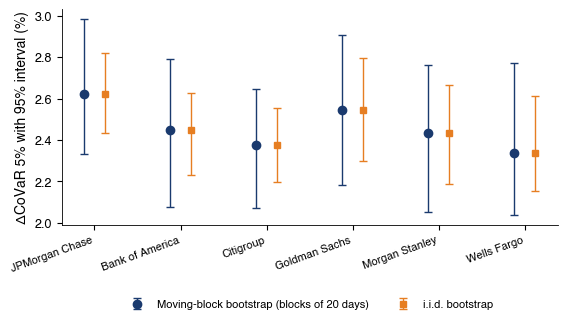

        b  var_i  covar  dcovar    lo    hi  iid_lo  iid_hi  var_sys
JPM  0.96   2.66   3.81    2.62  2.33  2.98    2.43    2.82     2.82
BAC  0.76   3.17   3.67    2.45  2.08  2.79    2.23    2.63     2.71
C    0.72   3.25   3.58    2.38  2.07  2.64    2.20    2.56     2.70
GS   0.89   2.79   3.93    2.54  2.18  2.91    2.30    2.80     2.81
MS   0.72   3.31   3.72    2.43  2.05  2.76    2.19    2.66     2.76
WFC  0.81   2.83   3.89    2.34  2.04  2.77    2.15    2.61     2.84


{'JPM': np.float64(0.878), 'BAC': np.float64(0.425), 'C': np.float64(0.019), 'GS': np.float64(0.048), 'MS': np.float64(0.746), 'WFC': np.float64(0.221)}
{'stat': 14.211078512714302, 'df': 5, 'p': np.float64(0.01432277536221306)}


[{'a': 'JPM',
  'b': 'BAC',
  'd': np.float64(0.17416426382366712),
  'se': np.float64(0.10858133610945152),
  'p': np.float64(0.10871445718154049),
  'p_holm': np.float64(1.0),
  'overlap': True},
 {'a': 'JPM',
  'b': 'C',
  'd': np.float64(0.24945241556676478),
  'se': np.float64(0.09405128666050735),
  'p': np.float64(0.00799450014348466),
  'p_holm': np.float64(0.18387350330014718),
  'overlap': True},
 {'a': 'JPM',
  'b': 'GS',
  'd': np.float64(0.08047069315797639),
  'se': np.float64(0.11208091202748346),
  'p': np.float64(0.4727760006033922),
  'p_holm': np.float64(1.0),
  'overlap': True},
 {'a': 'JPM',
  'b': 'MS',
  'd': np.float64(0.19139805036739066),
  'se': np.float64(0.11907427563504162),
  'p': np.float64(0.10797022235480036),
  'p_holm': np.float64(1.0),
  'overlap': True},
 {'a': 'JPM',
  'b': 'WFC',
  'd': np.float64(0.2860609596722403),
  'se': np.float64(0.09897925890844657),
  'p': np.float64(0.0038510687589976772),
  'p_holm': np.float64(0.09627671897494193),
  

In [16]:
def b1_us_dcovar5():
    """Delta-CoVaR 5% pentru bancile americane: interval bootstrap pe blocuri vs i.i.d."""
    out = {}
    rng = np.random.default_rng(SEED)
    for i, k in enumerate(US):
        xs, xi = system_ex(k, US).values, R[k].values
        c = covar_static(xs, xi, 0.05)
        lo, hi = covar_boot(xs, xi, 0.05, B=999, block=20, seed=SEED + i)
        iid = []
        for _ in range(999):
            idx = rng.integers(0, len(xi), len(xi))
            iid.append(covar_static(xs[idx], xi[idx], 0.05)['dcovar'])
        out[k] = {'b': c['b'], 'var_i': c['var_i'], 'covar': c['covar'], 'dcovar': c['dcovar'], 'lo': lo, 'hi': hi,
                  'iid_lo': np.percentile(iid, 2.5), 'iid_hi': np.percentile(iid, 97.5), 'var_sys': c['var_sys']}
    return out


def fig_b1(res):
    ks = list(res)
    xs = np.arange(len(ks))
    fig, ax = plt.subplots(figsize=(6.4, 2.8))
    d = np.array([res[k]['dcovar'] for k in ks])
    ax.errorbar(xs - 0.12, d, yerr=[d - [res[k]['lo'] for k in ks], np.array([res[k]['hi'] for k in ks]) - d],
                fmt='o', color=MainBlue, capsize=3, lw=1, label='Moving-block bootstrap (blocks of 20 days)')
    ax.errorbar(xs + 0.12, d, yerr=[d - [res[k]['iid_lo'] for k in ks], np.array([res[k]['iid_hi'] for k in ks]) - d],
                fmt='s', color=Orange, capsize=3, lw=1, ms=4, label='i.i.d. bootstrap')
    ax.set_xticks(xs)
    ax.set_xticklabels([NAMES[k] for k in ks], fontsize=8, rotation=20, ha='right')
    ax.set_ylabel('ΔCoVaR 5% with 95% interval (%)')
    legend_outside_bottom(ax, ncol=2, y=-0.3)
    save_fig('ch18_sem_b1')


b1 = b1_us_dcovar5()
fig_b1(b1)
print(pd.DataFrame(b1).T.round(2))
ct5 = covar_tests(0.05)   # several minutes
print({k: round(v['p_db'], 3) for k, v in ct5['banks'].items() if k in US})
print(ct5['wald_US'])
[p for p in ct5['pairs'] if p['a'] in US]

### B2. ΔCoVaR of European banks and the VaR ranking [Proposed]

- ΔCoVaR at 1% and 5%; pair tests with Holm; Spearman VaR vs ΔCoVaR with a block-bootstrap interval. Model: B1.

In [ ]:
# Your code here


### B3. SRISK as published: LRMES by simulation [Solved]

- GJR-GARCH(1,1) + DCC(1,1), resampled pairs of innovations, 22 days, market below −10% (Brownlees & Engle, 2017).
- Interpretation: why does LRMES change between March 2020 and today?

In [18]:
be, info = lrmes_sim(R.index[-1], 22, -0.10, 200000)   # several minutes
cv, _ = lrmes_sim(pd.Timestamp('2020-03-31'), 22, -0.10, 200000, SEED + 3)
pd.DataFrame({'today': {k: v['lrmes'] for k, v in be.items()}, '31.03.2020': {k: v['lrmes'] for k, v in cv.items()}}).round(3)

,today,31.03.2020
JPM,0.106,0.237
BAC,0.143,0.232
C,0.130,0.328
GS,0.165,0.250
MS,0.163,0.272
WFC,0.067,0.229
DBK,0.144,0.257
BNP,0.156,0.285
SAN,0.166,0.264
INGA,0.125,0.329


### B4. SRISK of a European and a Romanian bank [Proposed]

- Deutsche Bank and Banca Transilvania; L* with k = 5.5% from LRMES and its 90% range. Model: B3.

In [ ]:
# Your code here


### B5. How robust is the connectedness index? [Solved]

- VAR orders 1–4, horizons 5, 10, 20; generalized vs Cholesky.
- Interpretation: which choice moves the index most?

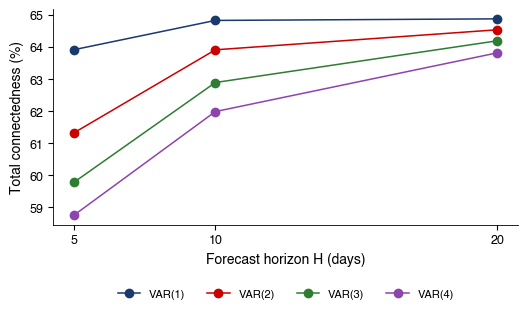

{'grid': {'p1_H5': np.float64(63.918739915151946),
  'p1_H10': np.float64(64.82856135138591),
  'p1_H20': np.float64(64.87746431358558),
  'p2_H5': np.float64(61.332315969413564),
  'p2_H10': np.float64(63.912446031455424),
  'p2_H20': np.float64(64.53665894080801),
  'p3_H5': np.float64(59.792634463637555),
  'p3_H10': np.float64(62.89236674722018),
  'p3_H20': np.float64(64.19282081807036),
  'p4_H5': np.float64(58.76700904619478),
  'p4_H10': np.float64(61.98674430224988),
  'p4_H20': np.float64(63.8169101735043)},
 'chol_us_first': np.float64(44.05699781048929),
 'chol_ro_first': np.float64(43.51917825118153),
 'gen': np.float64(64.82856135138591),
 'net_us_first': np.float64(65.92793495120091),
 'net_ro_first': np.float64(-95.93772147472195),
 'gen_net_us': np.float64(53.25030605377643)}

In [20]:
def b5_dy_sensitivity():
    """Indicele total pentru orizonturi H si ordine VAR p; generalizat vs Cholesky in doua ordini."""
    Y = V.values
    grid = {}
    for p in [1, 2, 3, 4]:
        A, S = var_fit(Y, p)
        for H in [5, 10, 20]:
            grid[f'p{p}_H{H}'] = spillover_table(gfevd(A, S, H), ALL)['total']
    A, S = var_fit(Y, 1)
    ch_us = spillover_table(cholesky_fevd(A, S, 10), ALL)
    ch_ro = spillover_table(cholesky_fevd(A, S, 10, order=list(range(len(ALL)))[::-1]), ALL)
    g = spillover_table(gfevd(A, S, 10), ALL)
    return {'grid': grid, 'chol_us_first': ch_us['total'], 'chol_ro_first': ch_ro['total'], 'gen': g['total'],
            'net_us_first': ch_us['net'][US].sum(), 'net_ro_first': ch_ro['net'][US].sum(),
            'gen_net_us': g['net'][US].sum()}


def fig_b5(res):
    fig, ax = plt.subplots(figsize=(6.0, 2.8))
    for p, c in zip([1, 2, 3, 4], [MainBlue, IDAred, Forest, Purple]):
        ax.plot([5, 10, 20], [res['grid'][f'p{p}_H{H}'] for H in [5, 10, 20]], 'o-', color=c, label=f'VAR({p})')
    ax.set_xticks([5, 10, 20])
    ax.set_xlabel('Forecast horizon H (days)')
    ax.set_ylabel('Total connectedness (%)')
    legend_outside_bottom(ax, ncol=4, y=-0.25)
    save_fig('ch18_sem_b5')


b5 = b5_dy_sensitivity()
fig_b5(b5)
b5

### B6. Did connectedness change after 2020? [Proposed]

- (a) Rolling index with a post-2020 dummy, ordinary vs Newey–West t; (b) subsample VARs with a residual bootstrap of the difference. Model: B5, B9.

In [ ]:
# Rolling connectedness index (input of B6)
tot, net = spill_rolling()
tot.to_csv(os.path.join(HERE, 'ch18_spill_rolling.csv'))

In [ ]:
# Your code here


### B7. The FRM penalty in one window [Solved]

- JPMorgan, 63 days, calm vs crisis window.
- Interpretation: why is the selected λ so small?

In [23]:
def b7_frm_window():
    """FRM intr-o fereastra: lambda GACV si legaturile active pentru JPMorgan (calm vs COVID-19)."""
    D = frm_design()
    out = {}
    for end in ['2019-06-28', '2020-03-31']:
        w = D.loc[:end].iloc[-63:]
        r = frm_window(w, 'JPM')
        names = [j for j in ALL if j != 'JPM'] + ['S&P 500 (t-1)', 'Euro Stoxx 50 (t-1)', 'VIX (t-1)']
        coef = pd.Series(r['coef'], index=names)
        act = coef[coef.abs() > 1e-8].sort_values(key=np.abs, ascending=False)
        out[end] = {'lambda': r['lambda'], 'df': r['df_sel'], 'active': {NAMES.get(k, k): v for k, v in act.head(4).items()},
                    'n_active': len(act), 'first': w.index[0]}
    return out


b7_frm_window()

{'2019-06-28': {'lambda': np.float64(4.548777947003778e-05),
  'df': 11,
  'active': {'Bank of America': 0.5171342439417581,
   'Santander': 0.25210736369375697,
   'Morgan Stanley': 0.18741215082539728,
   'ING': -0.11704134760804076},
  'n_active': 11,
  'first': Timestamp('2019-03-21 00:00:00')},
 '2020-03-31': {'lambda': np.float64(7.847599703514606e-05),
  'df': 12,
  'active': {'Bank of America': 0.39275080916987914,
   'Euro Stoxx 50 (t-1)': 0.37971898189105674,
   'BNP Paribas': 0.3420860962899162,
   'HSBC': 0.322214449023489},
  'n_active': 12,
  'first': Timestamp('2019-12-23 00:00:00')}}

### B8. Stress test of a Romanian bank portfolio [Proposed]

- 50% Banca Transilvania, 50% BRD; historical and hypothetical scenarios. Model: A7.
- Interpretation: domestic political shock or global pandemic?

In [ ]:
# Your code here


### B9. Which net spillovers are identified? [Solved]

- Residual block bootstrap (999 draws) of the full-sample VAR(1); intervals for total and net connectedness.
- Interpretation: which transmitter and receiver labels survive?

In [25]:
tot_b, net_b = spill_bootstrap(V.values, 1)   # several minutes
st = spillover_table(gfevd(*var_fit(V.values, 1), 10), ALL)
lo, hi = np.percentile(net_b, [2.5, 97.5], axis=0)
print('C', round(st['total'], 1), np.percentile(tot_b, [2.5, 97.5]).round(1))
pd.DataFrame({'net': st['net'], 'lo': lo, 'hi': hi}, index=ALL).round(1)

C 64.8 [60.7 67.1]


,net,lo,hi
JPM,12.6,6.7,18.5
BAC,12.4,6.9,16.9
C,15.6,8.7,21.6
GS,2.5,-2.4,8.7
MS,7.9,1.9,13.0
WFC,2.1,-5.0,9.1
DBK,-11.3,-16.1,-5.7
BNP,6.2,-0.3,12.3
SAN,-4.0,-10.8,2.8
INGA,7.5,-0.2,13.2


### B10. Backtesting the Girardi–Ergün CoVaR [Proposed]

- Expanding-window historical CoVaR at 5%; joint hits with probability α²; Kupiec test. Model: B1, A2.

In [ ]:
# Your code here


## Part C — exposure of Romanian banks to euro-area banking stress [Proposed]

- Exposure CoVaR of Banca Transilvania and BRD given European bank distress; subperiods; rolling connectedness from European and US banks.

In [ ]:
# Your code here
